## Module 9 Class activities
This notebook is a starting point for the exercises and activities that we'll do in class. We'll estimate topic models and do some sentiment analysis.

We'll continue with our example from last class: the [City of Palm Springs General Plan update](https://www.psgeneralplan.com).

Before you attempt any of these activities, make sure to watch the video lectures for this module.

### Reading and cleaning PDFs

Let's read in [this PDF of public comments](https://www.psgeneralplan.com/_files/ugd/89af76_0b8c3cd9a25140f4a9791570af8d6ba0.pdf). It's in the `data/` folder in your GitHub repository.

This is the code from last class. We read in the text of the PDF, and exclude the first 9 pages which are survey responses, not comments.

In [1]:
from pdfminer.high_level import extract_text

fn = 'data/PS_VP_Survey_Results_FINAL.pdf'
txt = extract_text(fn)
txt = txt[txt.find("It doesn"):]

txt[:200] # see what it looks like

'It doesn’t speak about the people that are neither residents nor visitors. I work here with a lot of\npride. But I don’t consider myself a visitor.\n\n3/25/2020 3:22 PM\n\nHeight restrictions that are actu'

Before we clean up the text further, let's split this into a list of comments. Note that each comment seems to be separated by `AM\n\n` or `PM\n\n`. So if we split on `M\n\n`, we should get a list of comments.

Once you have a list, now we can clean it up using regex. Here's my suggestion:
* write a function that takes a string, and returns a clean string (remove excess whitespace and characters that are not letters or a space)
* create a new list by applying this function to each element of your list of comments

The latter can be done with something like:

`newlist = [clean_string(comment) for comment in oldlist]`.

<div class="alert alert-block alert-info">
<strong>Exercise:</strong> Create a list of cleaned comments.
</div>

In [2]:
import re
def clean_string(comment):
    comment = re.sub(r"\s+", " ", comment)  # remove excess whitespace
    comment = re.sub(r"[^A-z\s]", "", comment)  # remove characters that are not letters\
    comment = re.sub(r"\s+", " ", comment)      # repeat step 1 to remove any new whitespace created in the previous step
    return comment
    
comments = txt.split('M\n\n')
comments = [clean_string(comment) for comment in comments]
comments[:10]

['It doesnt speak about the people that are neither residents nor visitors I work here with a lot of pride But I dont consider myself a visitor P',
 'Height restrictions that are actually adhered to Completion Bonds on all projects in Palm Springs P',
 ' James O Jessen Community Center updated Traffic lights crosswalk Pickleball courts Community Gardens and Art Park P',
 'Expand economic opportunities to include Green energy workforce training Workforce development to become a diversified economy Create more affordable Housing for single family residential P',
 'Many areas in the City are blighted and lack funding to advance the lower income areas of the Northern communities P',
 'Also needs to focus on health and wellbeing issues Revisit Economic Growth Incorporate Sustainability for local just visitors While we are a resort town residents seem to be forced out due to increase in sustaining visitorship Not sure at this point a reference to environmental issues is needed Change the phr

In [ ]:
import re
def clean_string(comment):
    # your code here
    return cleaned_comment

# create a list of comments
comments = 999 # # your code here 

# then a list of cleaned comments

One final cleaning step: you probably notice that all your comments end in `P` or `A`. 

Remove these terminal letters from each comment (or just delete the last two characters of each comment). And remove comments that are just ` P` or ` A` (perhaps you can ignore all comments that are less than, say, 5 characters long).

*Hint*: Try another list comprehension (or two).

<div class="alert alert-block alert-info">
<strong>Exercise:</strong> Clean up your comments further and drop the short ones.
</div>

In [5]:
# your code here

comments = [comment[:-2] for comment in comments] #remove last two characters
comments = [comment for comment in comments if len(comment)>=5] #drop short comments
comments[:10]

['It doesnt speak about the people that are neither residents nor visitors I work here with a lot of pride But I dont consider myself a visit',
 'Height restrictions that are actually adhered to Completion Bonds on all projects in Palm Sprin',
 ' James O Jessen Community Center updated Traffic lights crosswalk Pickleball courts Community Gardens and Art Pa',
 'Expand economic opportunities to include Green energy workforce training Workforce development to become a diversified economy Create more affordable Housing for single family residenti',
 'Many areas in the City are blighted and lack funding to advance the lower income areas of the Northern communiti',
 'Also needs to focus on health and wellbeing issues Revisit Economic Growth Incorporate Sustainability for local just visitors While we are a resort town residents seem to be forced out due to increase in sustaining visitorship Not sure at this point a reference to environmental issues is needed Change the phrasing word unity and

### Sentiment analysis
Now we have our cleaned up list of comments. Let's do some sentiment analysis. If we create a dataframe with our comments (as one column) and the polarity score (as a second column), the analysis later on becomes easier.

<div class="alert alert-block alert-info">
<strong>Exercise:</strong> Create a list of polarity scores, one for each comment. Then create a dataframe, with one column for the comment and one for the polarity score.</div>

In [6]:
from textblob import TextBlob
import pandas as pd

# your code here

In [17]:
polarity_score = [TextBlob(c).sentiment.polarity for c in comments]

In [18]:
commentsDf = pd.DataFrame({
    'comments': comments,
    'polarity_score': polarity_score
})

In [19]:
commentsDf

,comments,polarity_score
0,It doesnt speak about the people that are neit...,0.000000
1,Height restrictions that are actually adhered ...,0.000000
2,James O Jessen Community Center updated Traff...,-0.100000
3,Expand economic opportunities to include Green...,0.107143
4,Many areas in the City are blighted and lack f...,0.500000
...,...,...
445,Palm Springs General Plan Vision Priorities S...,0.060830
446,Stop the endless starting of projects that sta...,0.041667
447,Rewrite Priority to read Preserve protect cons...,-0.008333
448,Same response as two questions back If it isnt...,0.139125


Take a look at the comments with some of the highest and lowest polarity scores. Do the scores make sense? What words is it picking up on?

Note that a simple sentiment analyzer like TextBlob won't capture nuances, but in aggregate the results can be useful.

In [ ]:
# your code here

In [21]:
commentsDf.sort_values(by='polarity_score', ascending=False)

,comments,polarity_score
234,The PDDR E Zoning Affordability is Excellent N...,1.000000
13,Should also state accepts diversity that exist...,0.800000
209,We have all we need in retail I believe the ci...,0.666667
415,More bike lanes pleasewould be great if CV Lin...,0.650000
92,It is a good place to live in because the grea...,0.606061
...,...,...
397,This is vague also its redundant you already m...,-0.288889
34,Does not mention activitiesattractionsadventur...,-0.291667
60,link sustainable economic growth with a divers...,-0.300000
392,This is a joke The improvement Indian Canyon r...,-0.400000


<div class="alert alert-block alert-info">
<strong>Exercise:</strong> Do some plots of the sentiment and other analyses that try and capture sentiment on particular issues.</div>

For example, after you plot the overall sentiment scores (a histogram?), you might want to plot the scores where people mention specific issues. For example, you could add a column that is `True` if the comment mentions housing, and then plot the scores only for those rows. Experiment!

In [ ]:
# your code here

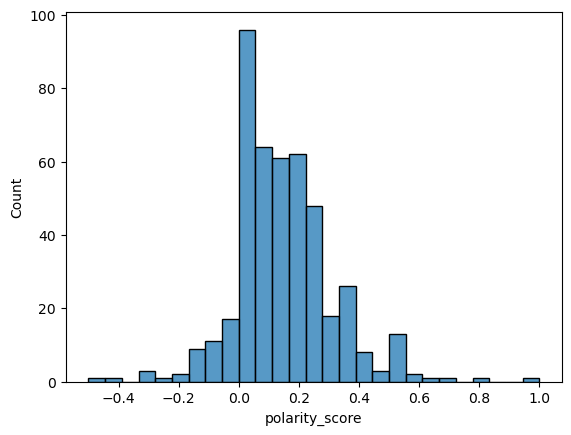

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

ax = sns.histplot(commentsDf, x='polarity_score')

In [ ]:
commentsDf['comments'] =

comments

## Topic modeling
Now let's see if we can identify different topics in the list of comments.

First, we'll need to do a bit more cleanup. For each comment, turn it into a list of words, and exclude stopwords. (After you see the results of your topic modeling, you might want to add more stopwords.) You should end up with a list of lists.

<div class="alert alert-block alert-info">
<strong>Exercise:</strong> Turn your list of comments into a list of lists of words, excluding stopwords.</div>

In [24]:
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize, sent_tokenize

# your code here

In [26]:
swords = stopwords.words('english')
wordlists = [[word for word in word_tokenize(comment.lower()) 
                 if word not in swords] 
                 for comment in comments]

<div class="alert alert-block alert-info">
<strong>Exercise:</strong> Estimate and visualize a topic model from your wordlists. Experiment with the number of topics and the other hyperparameters.</div>

Remember: 
* `alpha` controls the expected distribution of topics across documents. A higher value of `alpha` means that each document is expected to contain more of a mix of topics, rather than focusing on a few topics.
* `eta` (sometimes called beta) controls the expected distribution of words across topics. A higher value of `eta` means that topics are more similar in terms of their mixture of words.

In [28]:
import gensim
import pyLDAvis
import pyLDAvis.gensim_models 

# your code here

In [31]:
dictionary = gensim.corpora.Dictionary(wordlists)
pyLDAvis.enable_notebook()
pyLDAvis.gensim_models.prepare(model, corpus, dictionary)

/opt/anaconda3/envs/uds/lib/python3.12/site-packages/joblib/externals/loky/backend/fork_exec.py:38: DeprecationWarning: This process (pid=73674) is multi-threaded, use of fork() may lead to deadlocks in the child.
  pid = os.fork()
/opt/anaconda3/envs/uds/lib/python3.12/site-packages/joblib/externals/loky/backend/fork_exec.py:38: DeprecationWarning: This process (pid=73674) is multi-threaded, use of fork() may lead to deadlocks in the child.
  pid = os.fork()
/opt/anaconda3/envs/uds/lib/python3.12/site-packages/joblib/externals/loky/backend/fork_exec.py:38: DeprecationWarning: This process (pid=73674) is multi-threaded, use of fork() may lead to deadlocks in the child.
  pid = os.fork()
/opt/anaconda3/envs/uds/lib/python3.12/site-packages/joblib/externals/loky/backend/fork_exec.py:38: DeprecationWarning: This process (pid=73674) is multi-threaded, use of fork() may lead to deadlocks in the child.
  pid = os.fork()
/opt/anaconda3/envs/uds/lib/python3.12/site-packages/joblib/externals/lo

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
4      0.004216 -0.000443       1        1  31.478952
1     -0.004814  0.000549       2        1  18.284162
3     -0.000352 -0.003416       3        1  18.019810
2      0.001542  0.002469       4        1  17.496612
0     -0.000592  0.000841       5        1  14.720464, topic_info=           Term        Freq       Total Category  logprob  loglift
55         city  119.000000  119.000000  Default  30.0000  30.0000
45      housing   85.000000   85.000000  Default  29.0000  29.0000
175        need  102.000000  102.000000  Default  28.0000  28.0000
157  businesses   53.000000   53.000000  Default  27.0000  27.0000
123     springs  136.000000  136.000000  Default  26.0000  26.0000
..          ...         ...         ...      ...      ...      ...
105         new    4.894918   34.747936   Topic5  -6.0616  -0.0440
32      traffic    4.787458   33.821578   Topic5  -6.0838  -0.0392
2          dont    5.197119   43.625086   Topic5  -6.0017  -0.2116
157  businesses    5.384573   53.115326   Topic5  -5.9663  -0.3730
23    community    5.067876   46.360067   Topic5  -6.0269  -0.2976

[399 rows x 6 columns], token_table=      Topic      Freq    Term
term                         
241       1  0.286310  access
241       2  0.286310  access
241       3  0.143155  access
241       4  0.143155  access
241       5  0.143155  access
...     ...       ...     ...
582       1  0.292386    year
582       2  0.194924    year
582       3  0.194924    year
582       4  0.194924    year
582       5  0.194924    year

[987 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[5, 2, 4, 3, 1])

<div class="alert alert-block alert-info">
<strong>Exercise:</strong> Explain your topic model - write a sentence or two, and explain to your neighbor. What does each topic signify, and how did you choose alpha and eta?</div>

Your comments here.

## Extensions to topic modeling and sentiment analysis
One potential use of these models is to look at differences across space or across time. 

Or we could look at how word frequency changes across space or cities.

You could also feed the text to a generative AI API (e.g. the Google Gemini API which we experimented with in Week 2).

If you have time, try this with the San Francisco Board of Supervisors meetings. [This webpage](http://sanfrancisco.granicus.com/ViewPublisher.php?view_id=10) gives the archived transcripts ("caption notes").

You could scrape all of the URLs (that's a good exercise!), but for now, just manually create a list with a 10-20 or so of the caption notes.

Write a function that for a given URL:
* Gets the text (use `requests`)
* Cleans the text
* Tokenizes (splits into words)

Then, think about how you might estimate a topic model.

Would sentiment analysis be useful here?

This is an open-ended prompt, so spend some time thinking through the steps conceptually, even if you don't get far in implementing it. For example, how will you organize the text of each documents and the counts? In a list? A dataframe? Will you loop through each URL?

In [ ]:
# your code here

<div class="alert alert-block alert-info">
<h3>You should now be able to:</h3>
<ul>
  <li>Do further cleaning of text documents</li>
  <li>Estimate and interpret sentiments of texts</li>
  <li>Estimate and interpret topic models</li>
</ul>
</div>